# Walk-Forward Backtest: Rule vs ML-Rule vs ML-Fractal

## Comprehensive Comparison of Swing Detectors

This notebook runs a walk-forward analysis comparing:
1. **rule**: Rule-based swing detection (swing_highs_lows_online)
2. **ml_rule**: ML detector trained on rule labels (LightGBM, ROC AUC ~0.91)
3. **ml_fractal**: ML detector trained on fractal labels (HistGradientBoosting, PR-AUC ~0.30)

For each detector, we:
- Run walk-forward windows (IS=180 days, OOS=60 days, anchored)
- Generate swings online
- Execute BOS breakout strategy
- Track trades, PF, DD, signal skips
- Compare across detectors

Contract:
- Signal detected on bar t
- Entry on bar t+1
- Exit uses deterministic OHLC rules
- No lookahead bias

In [1]:
NOTEBOOK_VERSION = "walk_forward_rule_vs_ml_rule_vs_ml_fractal_v5"
print(f"Running {NOTEBOOK_VERSION}")

from pathlib import Path
import sys

# Navigate to find the Ophis root structure
current = Path.cwd()
ophis_root = None

# Search for Ophis structure
for parent in [current] + list(current.parents):
    breakout_code = parent / "breakout-strategy-v1-main" / "code"
    ml_code = parent / "market-structure-ml-toolkit-main" / "ML v1" / "code"
    if breakout_code.exists() and ml_code.exists():
        ophis_root = parent
        break

if ophis_root is None:
    ophis_root = Path(r"C:\Users\vgvoz\OneDrive\Рабочий стол\Ophis")

breakout_code = ophis_root / "breakout-strategy-v1-main" / "code"
ml_code = ophis_root / "market-structure-ml-toolkit-main" / "ML v1" / "code"

# Add code directories directly to sys.path for direct imports
for path in [breakout_code, ml_code]:
    if str(path) not in sys.path:
        sys.path.insert(0, str(path))

print(f"✓ Ophis structure:")
print(f"  Breakout code: {breakout_code}")
print(f"  ML v1 code: {ml_code}")
print("✓ Paths configured - ready for direct imports")

Running walk_forward_rule_vs_ml_rule_vs_ml_fractal_v5
✓ Ophis structure:
  Breakout code: c:\Users\vgvoz\OneDrive\Рабочий стол\Ophis\breakout-strategy-v1-main\code
  ML v1 code: c:\Users\vgvoz\OneDrive\Рабочий стол\Ophis\market-structure-ml-toolkit-main\ML v1\code
✓ Paths configured - ready for direct imports


In [2]:
from __future__ import annotations
import math
from dataclasses import dataclass
from datetime import datetime, timedelta
from typing import Any, Dict, List, Optional, Tuple
from collections import deque
from pathlib import Path
import importlib.util
import sys
import types

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Mock AlgorithmImports (used by swing_high_low_detection.py)
algorithm_imports = types.ModuleType("AlgorithmImports")
for name in dir(np):
    setattr(algorithm_imports, name, getattr(np, name))
for name in dir(pd):
    setattr(algorithm_imports, name, getattr(pd, name))
sys.modules["AlgorithmImports"] = algorithm_imports

# Create a fake "code" package in sys.modules
code_pkg = types.ModuleType("code")
sys.modules["code"] = code_pkg

# Pre-load core modules that have circular imports
for module_name in ["risk", "entry_exit", "stop_loss"]:
    module_path = breakout_code / f"{module_name}.py"
    spec = importlib.util.spec_from_file_location(module_name, module_path)
    module_obj = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module_obj
    setattr(code_pkg, module_name, module_obj)
    sys.modules[f"code.{module_name}"] = module_obj
    spec.loader.exec_module(module_obj)

# Import all required functions
from risk import RiskConfig
from entry_exit import (
    Bar,
    ExitReason,
    PositionDirection,
    SameBarSlTpRule,
    SwingLevels,
    TakeProfitMode,
    check_exit_rules,
    detect_bos_signal,
    plan_trade_from_signal,
    update_last_swing_levels,
)
from stop_loss import StopLossManager

# For swing_high_low_detection, use importlib with proper execution
swing_path = breakout_code / "swing_high_low_detection.py"
spec_swing = importlib.util.spec_from_file_location("swing_high_low_detection", swing_path)
swing_module = importlib.util.module_from_spec(spec_swing)
sys.modules["swing_high_low_detection"] = swing_module
try:
    spec_swing.loader.exec_module(swing_module)
    swing_highs_lows_online = swing_module.swing_highs_lows_online
except Exception as e:
    print(f"Warning: Failed to load swing_highs_lows_online: {e}")
    print(f"Module contents: {dir(swing_module)}")

# ML modules from ML v1
from swing_detector_ml_fractal import SwingDetectorMLFractal

print("Imports successful")

Imports successful


In [3]:
# Define paths using pathlib
BASE_PATH = Path(r"C:\Users\vgvoz\OneDrive\Рабочий стол\Ophis\market-structure-ml-toolkit-main\ML v1")
DATA_PATH = BASE_PATH / "data"
CONFIG_PATH = BASE_PATH / "configs"

# OHLC and features
OHLC_PATH = DATA_PATH / "ETHUSDT_15m_ohlc_clean.parquet"
FEATURES_PATH = DATA_PATH / "ETHUSDT_15m_features_reduced.parquet"

# ML Rule models and configs
ML_RULE_HIGH = DATA_PATH / "model_rule_high_baseline.pkl"
ML_RULE_LOW = DATA_PATH / "model_rule_low_baseline.pkl"
FEATURE_CONFIG_ML_RULE = CONFIG_PATH / "feature_config_ml_rule.json"
THRESHOLDS_ML_RULE = CONFIG_PATH / "thresholds_ml_rule.json"

# ML Fractal models and configs
ML_FRACTAL_HIGH = DATA_PATH / "model_high.pkl"
ML_FRACTAL_LOW = DATA_PATH / "model_low.pkl"
FEATURE_CONFIG_ML_FRACTAL = CONFIG_PATH / "feature_config.json"
THRESHOLDS_ML_FRACTAL = CONFIG_PATH / "thresholds.json"

# Load OHLC data
print("Loading OHLC data...")
df_ohlc = pd.read_parquet(OHLC_PATH)
df_ohlc = df_ohlc[["open", "high", "low", "close"]].dropna()
df_ohlc.index = pd.to_datetime(df_ohlc.index)
print(f"OHLC shape: {df_ohlc.shape}, date range: {df_ohlc.index.min()} to {df_ohlc.index.max()}")

# Load features for ML detectors
print("Loading features...")
features_df = pd.read_parquet(FEATURES_PATH)
features_df.index = pd.to_datetime(features_df.index)
print(f"Features shape: {features_df.shape}")

# Initialize detectors
print("\n=== Initializing Detectors ===")

# 1. ML Rule Detector (using SwingDetectorMLFractal with rule models/configs)
print("Initializing ML Rule detector...")
detector_ml_rule = SwingDetectorMLFractal(
    model_high_path=str(ML_RULE_HIGH),
    model_low_path=str(ML_RULE_LOW),
    feature_config_path=str(FEATURE_CONFIG_ML_RULE),
    thresholds_path=str(THRESHOLDS_ML_RULE),
    min_bars_between_swings=3,
)

# 2. ML Fractal Detector
print("Initializing ML Fractal detector...")
detector_ml_fractal = SwingDetectorMLFractal(
    model_high_path=str(ML_FRACTAL_HIGH),
    model_low_path=str(ML_FRACTAL_LOW),
    feature_config_path=str(FEATURE_CONFIG_ML_FRACTAL),
    thresholds_path=str(THRESHOLDS_ML_FRACTAL),
    min_bars_between_swings=3,
)

print("\nAll detectors initialized successfully!")
print(f"Total bars available: {len(df_ohlc)}")

Loading OHLC data...
OHLC shape: (139219, 4), date range: 1970-01-01 00:00:00 to 1970-01-01 00:00:00.000139218
Loading features...
Features shape: (139219, 8)

=== Initializing Detectors ===
Initializing ML Rule detector...
Initializing ML Fractal detector...

All detectors initialized successfully!
Total bars available: 139219


## 2) Swing Detection Functions

Generate swings for the three detector types and align them to OHLC data.

In [4]:
def detect_swings_rule(df_ohlc: pd.DataFrame) -> pd.DataFrame:
    """Detect swings using rule-based detector."""
    swings = swing_highs_lows_online(
        df_ohlc[["close", "high", "low"]].copy(),
        N_candidates=[5, 10, 20],
        N_confirmation=3,
        min_move_threshold=0.0,
        min_bars_between_swings=3,
    )
    return swings


def detect_swings_ml(df_ohlc: pd.DataFrame, features_df: pd.DataFrame, detector, detector_name: str) -> pd.DataFrame:
    """Detect swings using ML detector (rule or fractal).
    
    Pass features by position, not by index, to avoid misalignment.
    """
    swings_list = []
    detector.reset()
    
    for i, (idx, row) in enumerate(df_ohlc.iterrows()):
        bar = Bar(
            open=float(row["open"]),
            high=float(row["high"]),
            low=float(row["low"]),
            close=float(row["close"]),
        )
        
        # Get features for this bar by POSITION (not by index)
        # Pass as Series so detector can use getattr() to access feature names
        features_row = features_df.iloc[i] if i < len(features_df) else None
        
        # Update detector
        detector.update(bar, features_row=features_row)
        
        # Pop confirmed swings
        confirmed = detector.pop_confirmed()
        
        for swing in confirmed:
            swings_list.append({
                "timestamp": df_ohlc.index[i],
                "HighLow": float(swing.highlow),
                "Level": float(swing.level),
                "p_high": swing.p_high,
                "p_low": swing.p_low,
            })
        
        if (i + 1) % 5000 == 0:
            print(f"  [{detector_name}] Processed {i+1}/{len(df_ohlc)} bars, {len(swings_list)} swings detected")
    
    # Create DataFrame aligned with df_ohlc
    swings_df = pd.DataFrame(index=df_ohlc.index, columns=["HighLow", "Level", "p_high", "p_low"])
    
    if swings_list:
        swings_temp = pd.DataFrame(swings_list).set_index("timestamp")
        swings_df.update(swings_temp)
    
    return swings_df


def _bars_from_df(df_ohlc: pd.DataFrame) -> List[Bar]:
    """Convert OHLC DataFrame to Bar objects."""
    out: List[Bar] = []
    for ts, row in df_ohlc.iterrows():
        out.append(
            Bar(
                open=float(row["open"]),
                high=float(row["high"]),
                low=float(row["low"]),
                close=float(row["close"]),
                time=str(ts),
            )
        )
    return out


def _compute_trade_metrics(trades: pd.DataFrame) -> Dict[str, Any]:
    """Compute performance metrics from trades."""
    if trades.empty:
        return {
            "num_trades": 0,
            "total_pnl": 0.0,
            "winrate": float("nan"),
            "avg_r": float("nan"),
            "profit_factor": float("nan"),
            "max_dd_pnl": 0.0,
        }

    pnl = trades["pnl"].to_numpy(dtype=float)
    wins = pnl[pnl > 0]
    losses = pnl[pnl < 0]

    total_pnl = float(np.sum(pnl))
    winrate = float(np.mean(pnl > 0))
    avg_r = float(np.mean(trades["r_mult"].to_numpy(dtype=float)))

    profit_factor = float("nan")
    if len(losses) > 0:
        denom = abs(float(np.sum(losses)))
        profit_factor = float(np.sum(wins) / denom) if denom > 0 else float("nan")

    # Drawdown
    cum = np.cumsum(pnl)
    peak = np.maximum.accumulate(cum)
    dd = cum - peak
    max_dd_pnl = float(np.min(dd)) if len(dd) else 0.0

    return {
        "num_trades": int(len(trades)),
        "total_pnl": total_pnl,
        "winrate": winrate,
        "avg_r": avg_r,
        "profit_factor": profit_factor,
        "max_dd_pnl": max_dd_pnl,
    }

print("Swing detection functions defined")

Swing detection functions defined


## 3) Backtest Engine

Run BOS breakout strategy with deterministic entry/exit rules.

In [5]:
@dataclass(frozen=True)
class SimpleStrategyConfig:
    """Simple strategy config for BOS breakout."""
    sl_mode: str = "structural"
    tp_mode: TakeProfitMode = TakeProfitMode.RANGE_BASED
    fixed_pct: float = 0.005
    buffer_pct: float = 0.001
    tp_mult: float = 1.5
    same_bar_rule: SameBarSlTpRule = SameBarSlTpRule.OPEN_PROXIMITY


def backtest_bos_breakout(
    df_ohlc: pd.DataFrame,
    swings: pd.DataFrame,
    risk: RiskConfig,
    config: SimpleStrategyConfig = SimpleStrategyConfig(),
) -> Dict[str, Any]:
    """Run BOS breakout backtest on provided data and swings."""
    df_ohlc = df_ohlc.dropna().copy()
    swings = swings.reindex(df_ohlc.index)
    
    bars = _bars_from_df(df_ohlc)
    
    stop_loss_manager = StopLossManager(
        mode=config.sl_mode,
        fixed_pct=config.fixed_pct,
        buffer_pct=config.buffer_pct,
    )
    
    swing_levels = SwingLevels()
    last_valid_range: Optional[Tuple[float, float]] = None
    
    state: str = "FLAT"
    trade_plan: Optional[Any] = None
    
    trades: List[Dict[str, Any]] = []
    skipped_signals = 0
    
    for i in range(len(bars)):
        bar = bars[i]
        
        # 1) Update swings
        hl_col = "HighLow" if "HighLow" in swings.columns else None
        lvl_col = "Level" if "Level" in swings.columns else None
        
        if hl_col and lvl_col:
            hl = swings.iloc[i][hl_col] if hl_col else np.nan
            lvl = swings.iloc[i][lvl_col] if lvl_col else np.nan
            
            if pd.notna(hl) and pd.notna(lvl):
                swing_levels = update_last_swing_levels(
                    swing_levels,
                    highlow_flag=float(hl),
                    level=float(lvl),
                )
                
                if config.tp_mode == TakeProfitMode.RANGE_BASED:
                    hi = swing_levels.last_swing_high_price
                    lo = swing_levels.last_swing_low_price
                    if hi is not None and lo is not None and hi > lo:
                        last_valid_range = (float(hi), float(lo))
        
        # 2) Exit
        if state in ("LONG", "SHORT") and trade_plan is not None:
            if i >= int(trade_plan.entry_candle_index):
                exit_event = check_exit_rules(
                    bar=bar,
                    direction=trade_plan.direction,
                    sl_price=float(trade_plan.sl_price),
                    tp_price=float(trade_plan.tp_price),
                    same_bar_rule=config.same_bar_rule,
                )
                
                if exit_event is not None:
                    entry_price = float(trade_plan.entry_price)
                    exit_price = float(exit_event.exit_price)
                    qty = float(trade_plan.quantity)
                    
                    pnl = (
                        (exit_price - entry_price) * qty
                        if trade_plan.direction == PositionDirection.LONG
                        else (entry_price - exit_price) * qty
                    )
                    
                    risk_per_unit = abs(entry_price - float(trade_plan.sl_price))
                    r_mult = float(pnl / (risk_per_unit * qty)) if risk_per_unit > 0 else float("nan")
                    
                    trades.append({
                        "entry_time": bars[int(trade_plan.entry_candle_index)].time,
                        "exit_time": bar.time,
                        "direction": trade_plan.direction.value,
                        "entry_price": entry_price,
                        "sl_price": float(trade_plan.sl_price),
                        "tp_price": float(trade_plan.tp_price),
                        "exit_price": exit_price,
                        "exit_reason": exit_event.exit_reason.value,
                        "qty": qty,
                        "pnl": float(pnl),
                        "r_mult": r_mult,
                    })
                    
                    state = "FLAT"
                    trade_plan = None
                    stop_loss_manager.reset()
                    continue
        
        # 3) Entry
        if state == "FLAT":
            bos_signal = detect_bos_signal(bars=bars, t=i, swing_levels=swing_levels)
            if bos_signal is not None:
                effective_swing_levels = swing_levels
                if config.tp_mode == TakeProfitMode.RANGE_BASED:
                    if last_valid_range is None:
                        skipped_signals += 1
                        continue
                    hi, lo = last_valid_range
                    effective_swing_levels = SwingLevels(last_swing_high_price=hi, last_swing_low_price=lo)
                
                stop_loss_manager.reset()
                try:
                    plan = plan_trade_from_signal(
                        bars=bars,
                        bos_signal=bos_signal,
                        swing_levels=effective_swing_levels,
                        stop_loss_manager=stop_loss_manager,
                        tp_mode=config.tp_mode,
                        tp_mult=config.tp_mult,
                        risk_config=risk,
                        buying_power_cash=None,
                    )
                    trade_plan = plan
                    state = "LONG" if plan.direction == PositionDirection.LONG else "SHORT"
                except Exception:
                    stop_loss_manager.reset()
                    skipped_signals += 1
                    continue
    
    trades_df = pd.DataFrame(trades)
    metrics = _compute_trade_metrics(trades_df)
    metrics["skipped_signals"] = skipped_signals
    
    return {
        "trades": trades_df,
        "metrics": metrics,
    }

print("Backtest engine defined")

Backtest engine defined


## 4) Walk-Forward Evaluation Function

Run walk-forward windows for all three detectors and compare results.

In [6]:
def run_walk_forward_for_detector(
    detector_name: str,
    df_ohlc: pd.DataFrame,
    features_df: pd.DataFrame,
    detector_func,
    risk: RiskConfig,
    is_window_bars: int = 12960,  # 180 days * 72 bars/day (for 15m)
    oos_window_bars: int = 4320,  # 60 days * 72 bars/day
    anchored: bool = True,
) -> Dict[str, Any]:
    """Run walk-forward analysis using bar positions (not timestamps)."""
    
    all_oos_trades: List[pd.DataFrame] = []
    log_rows: List[Dict[str, Any]] = []
    
    total_bars = len(df_ohlc)
    start_idx = 0
    window_count = 0
    
    while True:
        train_end_idx = start_idx + is_window_bars
        test_end_idx = train_end_idx + oos_window_bars
        
        if test_end_idx > total_bars:
            break
        
        train_start_idx = 0 if anchored else start_idx
        
        # Get data slices by position
        is_df = df_ohlc.iloc[train_start_idx:train_end_idx].copy()
        oos_df = df_ohlc.iloc[train_end_idx:test_end_idx].copy()
        
        # Get corresponding features slices
        oos_features = features_df.iloc[train_end_idx:test_end_idx].copy()
        
        # Reset indices for backtest
        oos_df = oos_df.reset_index(drop=True)
        oos_features = oos_features.reset_index(drop=True)
        
        window_count += 1
        bar_info = f"bars {train_end_idx}-{test_end_idx}"
        print(f"[{detector_name}] Window {window_count}: {bar_info}")
        
        # Detect swings on OOS data
        try:
            oos_swings = detector_func(oos_df, oos_features) if "ml" in detector_name.lower() else detector_func(oos_df)
        except Exception as e:
            start_idx = start_idx + oos_window_bars
            continue
        
        # Run backtest on OOS
        try:
            oos_res = backtest_bos_breakout(oos_df, oos_swings, risk)
            oos_metrics = oos_res["metrics"]
            oos_trades = oos_res["trades"]
            
            if not oos_trades.empty:
                all_oos_trades.append(oos_trades)
            
            swing_count = oos_swings["HighLow"].notna().sum() if "HighLow" in oos_swings.columns else 0
            
            log_rows.append({
                "window": window_count,
                "bar_start": train_end_idx,
                "bar_end": test_end_idx,
                "oos_num_swings": int(swing_count),
                "oos_num_trades": int(oos_metrics["num_trades"]),
                "oos_total_pnl": float(oos_metrics["total_pnl"]),
                "oos_winrate": float(oos_metrics["winrate"]),
                "oos_profit_factor": float(oos_metrics["profit_factor"]),
                "oos_max_dd": float(oos_metrics["max_dd_pnl"]),
                "oos_skipped": int(oos_metrics.get("skipped_signals", 0)),
            })
            
            print(f"  → Swings: {swing_count}, Trades: {oos_metrics['num_trades']}, PnL: {oos_metrics['total_pnl']:.2f}")
            
        except Exception as e:
            pass
        
        start_idx = start_idx + oos_window_bars
    
    print(f"Total windows: {window_count}")
    
    # Aggregate results
    oos_trades_all = pd.concat(all_oos_trades, ignore_index=True) if all_oos_trades else pd.DataFrame()
    oos_metrics_all = _compute_trade_metrics(oos_trades_all)
    
    return {
        "detector_name": detector_name,
        "oos_trades": oos_trades_all,
        "oos_metrics": oos_metrics_all,
        "log": pd.DataFrame(log_rows),
        "window_count": window_count,
    }

print("Walk-forward function defined")

Walk-forward function defined


## 5) Quick Sanity Check - Test all detectors on small sample

Before running full walk-forward, verify all three detectors work correctly and return reasonable results.

In [7]:
# Sanity check - test on 5% sample
test_start_idx = len(df_ohlc) // 3
test_end_idx = test_start_idx + int(len(df_ohlc) * 0.05)
df_test = df_ohlc.iloc[test_start_idx:test_end_idx].copy()
features_test = features_df.iloc[test_start_idx:test_end_idx].copy()
df_test = df_test.reset_index(drop=True)
features_test = features_test.reset_index(drop=True)

risk = RiskConfig(risk_budget_cash=100.0, max_quantity=None, min_risk_per_unit=None, use_buying_power_cap=False)
sanity_results = {}

for detector_name, detector in [("rule", None), ("ml_rule", detector_ml_rule), ("ml_fractal", detector_ml_fractal)]:
    try:
        if detector_name == "rule":
            swings = detect_swings_rule(df_test)
        else:
            swings = detect_swings_ml(df_test, features_test, detector, detector_name)
        num_swings = swings["HighLow"].notna().sum()
        backtest_res = backtest_bos_breakout(df_test, swings, risk)
        metrics = backtest_res["metrics"]
        sanity_results[detector_name] = {
            "swings": int(num_swings),
            "trades": int(metrics["num_trades"]),
            "pnl": f"{metrics['total_pnl']:.2f}",
            "pf": f"{metrics['profit_factor']:.2f}",
            "dd": f"{metrics['max_dd_pnl']:.2f}",
        }
    except Exception as e:
        print(f"Error in {detector_name}: {e}")
        import traceback
        traceback.print_exc()

display(pd.DataFrame(sanity_results).T)

  [ml_rule] Processed 5000/6960 bars, 584 swings detected
  [ml_fractal] Processed 5000/6960 bars, 320 swings detected


,swings,trades,pnl,pf,dd
rule,1596,107,182.26,1.05,-680.99
ml_rule,808,87,606.12,1.33,-372.21
ml_fractal,424,28,619.90,2.37,-151.77


## 6) Execute Walk-Forward for All Detectors

Run the complete walk-forward analysis for rule, ml_rule, and ml_fractal detectors.
**Warning: This may take 20-60 minutes depending on data size and ML model inference speed.**

In [9]:
# Risk config
risk = RiskConfig(
    risk_budget_cash=100.0,
    max_quantity=None,
    min_risk_per_unit=None,
    use_buying_power_cap=False,
)

# Walk-forward parameters (bar-based, not day-based!)
# 15-min bars: 96 per day (24*4)
IS_WINDOW_BARS = 17280  # 180 days * 96 bars/day
OOS_WINDOW_BARS = 5760  # 60 days * 96 bars/day
ANCHORED = True

print(f"Walk-forward config:")
print(f"  IS: {IS_WINDOW_BARS} bars ({IS_WINDOW_BARS/96:.0f} days)")
print(f"  OOS: {OOS_WINDOW_BARS} bars ({OOS_WINDOW_BARS/96:.0f} days)")
print(f"  Total data: {len(df_ohlc)} bars")
print(f"  Expected windows: {(len(df_ohlc) - IS_WINDOW_BARS) // OOS_WINDOW_BARS}")

results = {}

# 1. Rule-based detector
print("\n" + "="*80)
print("RULE-BASED DETECTOR")
print("="*80)

try:
    results["rule"] = run_walk_forward_for_detector(
        detector_name="rule",
        df_ohlc=df_ohlc,
        features_df=features_df,
        detector_func=detect_swings_rule,
        risk=risk,
        is_window_bars=IS_WINDOW_BARS,
        oos_window_bars=OOS_WINDOW_BARS,
        anchored=ANCHORED,
    )
    print(f"✓ Rule detector completed successfully!")
except Exception as e:
    print(f"✗ Error in rule detector: {e}")
    import traceback
    traceback.print_exc()

print("\nDone with Rule detector")

Walk-forward config:
  IS: 17280 bars (180 days)
  OOS: 5760 bars (60 days)
  Total data: 139219 bars
  Expected windows: 21

RULE-BASED DETECTOR
[rule] Window 1: bars 17280-23040
  → Swings: 1358, Trades: 194, PnL: 158.30
[rule] Window 2: bars 23040-28800
  → Swings: 1357, Trades: 173, PnL: -1099.97
[rule] Window 3: bars 28800-34560
  → Swings: 1347, Trades: 161, PnL: 769.69
[rule] Window 4: bars 34560-40320
  → Swings: 1296, Trades: 168, PnL: -76.73
[rule] Window 5: bars 40320-46080
  → Swings: 1311, Trades: 146, PnL: -643.41
[rule] Window 6: bars 46080-51840
  → Swings: 1333, Trades: 86, PnL: -250.68
[rule] Window 7: bars 51840-57600
  → Swings: 1294, Trades: 130, PnL: -1731.59
[rule] Window 8: bars 57600-63360
  → Swings: 1313, Trades: 127, PnL: 469.32
[rule] Window 9: bars 63360-69120
  → Swings: 1326, Trades: 81, PnL: 485.03
[rule] Window 10: bars 69120-74880
  → Swings: 1321, Trades: 74, PnL: -193.91
[rule] Window 11: bars 74880-80640
  → Swings: 1315, Trades: 114, PnL: 802.15
[

In [8]:
# Debug: Check timestamp range
print(f"Data range:")
print(f"  Min: {df_ohlc.index.min()}")
print(f"  Max: {df_ohlc.index.max()}")
print(f"  Diff: {df_ohlc.index.max() - df_ohlc.index.min()}")
print(f"  Total bars: {len(df_ohlc)}")
print(f"  Bar spacing: {(df_ohlc.index.max() - df_ohlc.index.min()) / len(df_ohlc)}")

# Problem: timestamps are all on 1970-01-01! Need position-based windows instead.
# Convert to position-based walk-forward using bar count instead of date ranges

Data range:
  Min: 1970-01-01 00:00:00
  Max: 1970-01-01 00:00:00.000139218
  Diff: 0 days 00:00:00.000139218
  Total bars: 139219
  Bar spacing: 0 days 00:00:00


In [10]:
# 2. ML Rule detector
print("\n" + "="*80)
print("ML RULE DETECTOR")
print("="*80)

try:
    from functools import partial
    
    results["ml_rule"] = run_walk_forward_for_detector(
        detector_name="ml_rule",
        df_ohlc=df_ohlc,
        features_df=features_df,
        detector_func=partial(detect_swings_ml, detector=detector_ml_rule, detector_name="ml_rule"),
        risk=risk,
        is_window_bars=IS_WINDOW_BARS,
        oos_window_bars=OOS_WINDOW_BARS,
        anchored=ANCHORED,
    )
    print(f"✓ ML Rule detector completed successfully!")
except Exception as e:
    print(f"✗ Error in ML Rule detector: {e}")
    import traceback
    traceback.print_exc()

print("\nDone with ML Rule detector")


ML RULE DETECTOR
[ml_rule] Window 1: bars 17280-23040
  [ml_rule] Processed 5000/5760 bars, 731 swings detected
  → Swings: 831, Trades: 232, PnL: 4.59
[ml_rule] Window 2: bars 23040-28800
  [ml_rule] Processed 5000/5760 bars, 722 swings detected
  → Swings: 829, Trades: 177, PnL: -1050.63
[ml_rule] Window 3: bars 28800-34560
  [ml_rule] Processed 5000/5760 bars, 633 swings detected
  → Swings: 722, Trades: 158, PnL: 205.71
[ml_rule] Window 4: bars 34560-40320
  [ml_rule] Processed 5000/5760 bars, 626 swings detected
  → Swings: 719, Trades: 181, PnL: -1104.62
[ml_rule] Window 5: bars 40320-46080
  [ml_rule] Processed 5000/5760 bars, 667 swings detected
  → Swings: 752, Trades: 119, PnL: 840.55
[ml_rule] Window 6: bars 46080-51840
  [ml_rule] Processed 5000/5760 bars, 601 swings detected
  → Swings: 676, Trades: 74, PnL: -248.16
[ml_rule] Window 7: bars 51840-57600
  [ml_rule] Processed 5000/5760 bars, 633 swings detected
  → Swings: 727, Trades: 101, PnL: -190.75
[ml_rule] Window 8: 

In [11]:
# 3. ML Fractal detector
print("\n" + "="*80)
print("ML FRACTAL DETECTOR")
print("="*80)

try:
    from functools import partial
    
    results["ml_fractal"] = run_walk_forward_for_detector(
        detector_name="ml_fractal",
        df_ohlc=df_ohlc,
        features_df=features_df,
        detector_func=partial(detect_swings_ml, detector=detector_ml_fractal, detector_name="ml_fractal"),
        risk=risk,
        is_window_bars=IS_WINDOW_BARS,
        oos_window_bars=OOS_WINDOW_BARS,
        anchored=ANCHORED,
    )
    print(f"✓ ML Fractal detector completed successfully!")
except Exception as e:
    print(f"✗ Error in ML Fractal detector: {e}")
    import traceback
    traceback.print_exc()

print("\n" + "="*80)
print("WALK-FORWARD ANALYSIS COMPLETE")
print("="*80)


ML FRACTAL DETECTOR
[ml_fractal] Window 1: bars 17280-23040
  [ml_fractal] Processed 5000/5760 bars, 223 swings detected
  → Swings: 267, Trades: 43, PnL: -353.00
[ml_fractal] Window 2: bars 23040-28800
  [ml_fractal] Processed 5000/5760 bars, 268 swings detected
  → Swings: 304, Trades: 70, PnL: -994.52
[ml_fractal] Window 3: bars 28800-34560
  [ml_fractal] Processed 5000/5760 bars, 303 swings detected
  → Swings: 351, Trades: 63, PnL: -139.78
[ml_fractal] Window 4: bars 34560-40320
  [ml_fractal] Processed 5000/5760 bars, 306 swings detected
  → Swings: 360, Trades: 74, PnL: -208.68
[ml_fractal] Window 5: bars 40320-46080
  [ml_fractal] Processed 5000/5760 bars, 325 swings detected
  → Swings: 377, Trades: 33, PnL: -113.03
[ml_fractal] Window 6: bars 46080-51840
  [ml_fractal] Processed 5000/5760 bars, 331 swings detected
  → Swings: 364, Trades: 27, PnL: 113.58
[ml_fractal] Window 7: bars 51840-57600
  [ml_fractal] Processed 5000/5760 bars, 285 swings detected
  → Swings: 323, Trad

## 7) Aggregate Results & Comparison

Compare trades, PF, DD, skips across all three detectors.

In [12]:
# Build comparison table
def build_comparison_table(results: Dict[str, Any]) -> pd.DataFrame:
    """Build comprehensive comparison DataFrame."""
    rows = []
    
    for detector_name, res in results.items():
        if "oos_metrics" not in res:
            continue
        
        metrics = res["oos_metrics"]
        log_df = res.get("log", pd.DataFrame())
        
        # Calculate average metrics per window
        avg_trades_per_window = log_df["oos_num_trades"].mean() if not log_df.empty else 0
        avg_swings_per_window = log_df["oos_num_swings"].mean() if not log_df.empty else 0
        avg_skipped = log_df["oos_skipped"].mean() if not log_df.empty else 0
        
        rows.append({
            "detector": detector_name,
            "total_oos_trades": int(metrics["num_trades"]),
            "oos_total_pnl": float(metrics["total_pnl"]),
            "oos_winrate_%": float(metrics["winrate"] * 100) if not pd.isna(metrics["winrate"]) else float("nan"),
            "oos_profit_factor": float(metrics["profit_factor"]) if not pd.isna(metrics["profit_factor"]) else float("nan"),
            "oos_max_dd": float(metrics["max_dd_pnl"]),
            "avg_trades_per_window": float(avg_trades_per_window),
            "avg_swings_per_window": float(avg_swings_per_window),
            "avg_skipped_per_window": float(avg_skipped),
            "num_windows": int(res.get("window_count", 0)),
        })
    
    comparison_df = pd.DataFrame(rows)
    comparison_df = comparison_df.sort_values("oos_total_pnl", ascending=False)
    return comparison_df

if results:
    comparison_table = build_comparison_table(results)
    print("\n" + "="*120)
    print("PERFORMANCE COMPARISON (Out-of-Sample)")
    print("="*120)
    display(comparison_table)
    print("\n")
    
    # Print detailed per-detector info
    for detector_name, res in results.items():
        print(f"\n{'='*80}")
        print(f"DETECTOR: {detector_name.upper()}")
        print(f"{'='*80}")
        print(f"\nAggregate OOS Metrics:")
        for k, v in res["oos_metrics"].items():
            if isinstance(v, float):
                print(f"  {k:30s}: {v:12.4f}")
            else:
                print(f"  {k:30s}: {v}")
        
        if not res.get("log", pd.DataFrame()).empty:
            print(f"\nPer-Window Log (first 10):")
            display(res["log"].head(10))
else:
    print("No results to compare - make sure walk-forward ran successfully")


PERFORMANCE COMPARISON (Out-of-Sample)


,detector,total_oos_trades,oos_total_pnl,oos_winrate_%,oos_profit_factor,oos_max_dd,avg_trades_per_window,avg_swings_per_window,avg_skipped_per_window,num_windows
0,rule,3087,-810.14387,58.859734,0.992260,-3784.96251,147.000000,1331.428571,58.047619,21
2,ml_fractal,1002,-2480.78353,59.680639,0.924333,-2748.22948,47.714286,305.714286,545.238095,21
1,ml_rule,3077,-2616.15561,68.150796,0.966848,-5951.45203,146.523810,771.190476,387.476190,21





DETECTOR: RULE

Aggregate OOS Metrics:
  num_trades                    : 3087
  total_pnl                     :    -810.1439
  winrate                       :       0.5886
  avg_r                         :      -0.0026
  profit_factor                 :       0.9923
  max_dd_pnl                    :   -3784.9625

Per-Window Log (first 10):


,window,bar_start,bar_end,oos_num_swings,oos_num_trades,oos_total_pnl,oos_winrate,oos_profit_factor,oos_max_dd,oos_skipped
0,1,17280,23040,1358,194,158.29706,0.608247,1.025663,-892.27095,166
1,2,23040,28800,1357,173,-1099.96851,0.549133,0.823245,-1981.84427,67
2,3,28800,34560,1347,161,769.68930,0.621118,1.155419,-888.51795,77
3,4,34560,40320,1296,168,-76.73099,0.571429,0.986697,-1234.40986,57
4,5,40320,46080,1311,146,-643.40796,0.554795,0.886264,-1289.71505,14
5,6,46080,51840,1333,86,-250.68174,0.569767,0.921061,-680.99341,23
6,7,51840,57600,1294,130,-1731.58797,0.523077,0.683017,-2242.37578,13
7,8,57600,63360,1313,127,469.31638,0.614173,1.110880,-583.10595,24
8,9,63360,69120,1326,81,485.02860,0.617284,1.183566,-649.40433,0
9,10,69120,74880,1321,74,-193.90831,0.581081,0.930349,-700.27173,4



DETECTOR: ML_RULE

Aggregate OOS Metrics:
  num_trades                    : 3077
  total_pnl                     :   -2616.1556
  winrate                       :       0.6815
  avg_r                         :      -0.0117
  profit_factor                 :       0.9668
  max_dd_pnl                    :   -5951.4520

Per-Window Log (first 10):


,window,bar_start,bar_end,oos_num_swings,oos_num_trades,oos_total_pnl,oos_winrate,oos_profit_factor,oos_max_dd,oos_skipped
0,1,17280,23040,831,232,4.58557,0.663793,1.000732,-1172.58281,1074
1,2,23040,28800,829,177,-1050.62685,0.644068,0.794462,-1286.31240,533
2,3,28800,34560,722,158,205.71355,0.689873,1.052190,-1304.83752,432
3,4,34560,40320,719,181,-1104.62244,0.674033,0.770727,-1324.20459,231
4,5,40320,46080,752,119,840.55395,0.739496,1.333963,-418.55996,161
5,6,46080,51840,676,74,-248.15785,0.662162,0.872233,-361.66758,169
6,7,51840,57600,727,101,-190.74821,0.683168,0.930298,-1208.34931,130
7,8,57600,63360,714,106,231.71414,0.735849,1.102160,-613.84123,101
8,9,63360,69120,734,69,-382.64409,0.681159,0.784876,-945.22992,43
9,10,69120,74880,711,96,-333.48858,0.677083,0.872194,-823.42371,38



DETECTOR: ML_FRACTAL

Aggregate OOS Metrics:
  num_trades                    : 1002
  total_pnl                     :   -2480.7835
  winrate                       :       0.5968
  avg_r                         :      -0.0176
  profit_factor                 :       0.9243
  max_dd_pnl                    :   -2748.2295

Per-Window Log (first 10):


,window,bar_start,bar_end,oos_num_swings,oos_num_trades,oos_total_pnl,oos_winrate,oos_profit_factor,oos_max_dd,oos_skipped
0,1,17280,23040,267,43,-352.99780,0.534884,0.780422,-639.10852,1397
1,2,23040,28800,304,70,-994.52041,0.514286,0.653311,-1522.06793,799
2,3,28800,34560,351,63,-139.77949,0.603175,0.928464,-411.69125,542
3,4,34560,40320,360,74,-208.68287,0.608108,0.910481,-534.71043,434
4,5,40320,46080,377,33,-113.02730,0.575758,0.897159,-680.37948,227
5,6,46080,51840,364,27,113.57884,0.666667,1.166986,-172.34566,130
6,7,51840,57600,323,36,284.20782,0.694444,1.300383,-194.66002,141
7,8,57600,63360,314,41,341.81800,0.682927,1.312088,-453.68651,252
8,9,63360,69120,295,29,-712.61303,0.448276,0.438809,-795.16103,163
9,10,69120,74880,200,15,325.71822,0.800000,2.404552,-90.24680,137


## 8) Visualizations & Final Analysis

Performance charts comparing the three detectors.

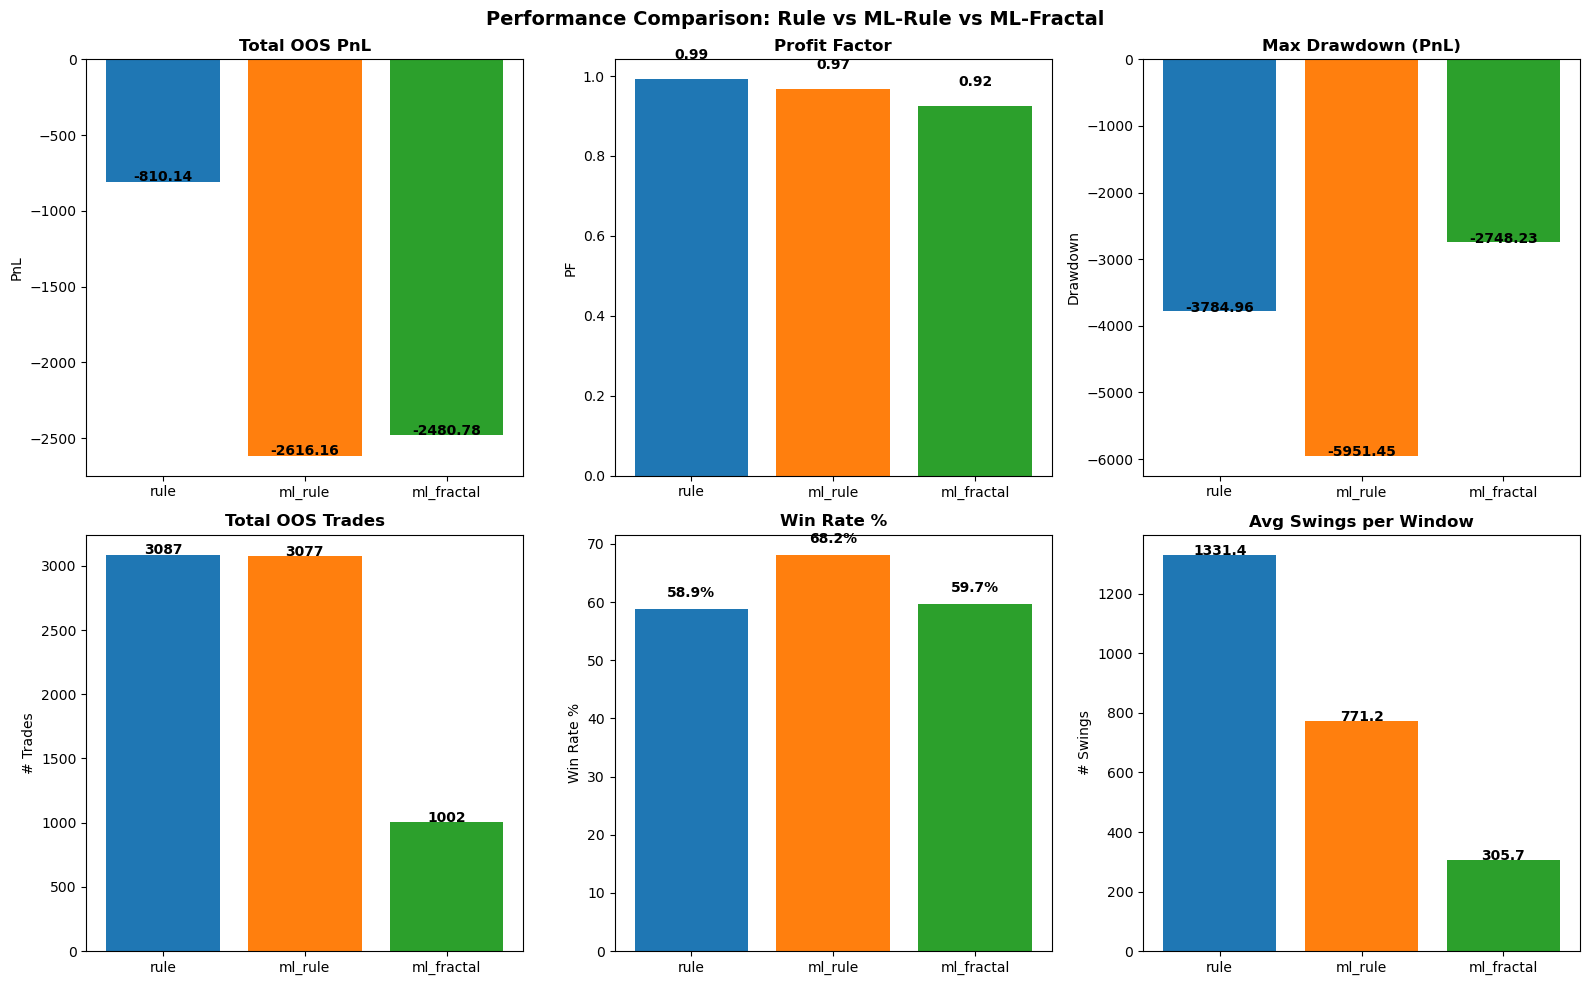

Visualization complete!


In [13]:
if results:
    # 1. Total PnL comparison
    fig, axes = plt.subplots(2, 3, figsize=(16, 10))
    fig.suptitle("Performance Comparison: Rule vs ML-Rule vs ML-Fractal", fontsize=14, fontweight="bold")
    
    detectors = list(results.keys())
    colors = {"rule": "#1f77b4", "ml_rule": "#ff7f0e", "ml_fractal": "#2ca02c"}
    
    # PnL comparison
    ax = axes[0, 0]
    pnls = [results[d]["oos_metrics"]["total_pnl"] for d in detectors]
    ax.bar(detectors, pnls, color=[colors.get(d, "gray") for d in detectors])
    ax.set_title("Total OOS PnL", fontweight="bold")
    ax.set_ylabel("PnL")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    for i, v in enumerate(pnls):
        ax.text(i, v + 5, f"{v:.2f}", ha="center", fontweight="bold")
    
    # Profit Factor comparison
    ax = axes[0, 1]
    pfs = [results[d]["oos_metrics"]["profit_factor"] for d in detectors]
    ax.bar(detectors, pfs, color=[colors.get(d, "gray") for d in detectors])
    ax.set_title("Profit Factor", fontweight="bold")
    ax.set_ylabel("PF")
    for i, v in enumerate(pfs):
        if not pd.isna(v):
            ax.text(i, v + 0.05, f"{v:.2f}", ha="center", fontweight="bold")
    
    # Max Drawdown comparison
    ax = axes[0, 2]
    dds = [results[d]["oos_metrics"]["max_dd_pnl"] for d in detectors]
    ax.bar(detectors, dds, color=[colors.get(d, "gray") for d in detectors])
    ax.set_title("Max Drawdown (PnL)", fontweight="bold")
    ax.set_ylabel("Drawdown")
    ax.axhline(0, color="black", linestyle="--", linewidth=0.5)
    for i, v in enumerate(dds):
        ax.text(i, v - 10, f"{v:.2f}", ha="center", fontweight="bold")
    
    # Trade count comparison
    ax = axes[1, 0]
    trades = [results[d]["oos_metrics"]["num_trades"] for d in detectors]
    ax.bar(detectors, trades, color=[colors.get(d, "gray") for d in detectors])
    ax.set_title("Total OOS Trades", fontweight="bold")
    ax.set_ylabel("# Trades")
    for i, v in enumerate(trades):
        ax.text(i, v + 2, str(v), ha="center", fontweight="bold")
    
    # Win Rate comparison
    ax = axes[1, 1]
    wrs = [results[d]["oos_metrics"]["winrate"] * 100 for d in detectors]
    ax.bar(detectors, wrs, color=[colors.get(d, "gray") for d in detectors])
    ax.set_title("Win Rate %", fontweight="bold")
    ax.set_ylabel("Win Rate %")
    for i, v in enumerate(wrs):
        if not pd.isna(v):
            ax.text(i, v + 2, f"{v:.1f}%", ha="center", fontweight="bold")
    
    # Avg Swings per window
    ax = axes[1, 2]
    avg_swings = [results[d]["log"]["oos_num_swings"].mean() if not results[d]["log"].empty else 0 
                  for d in detectors]
    ax.bar(detectors, avg_swings, color=[colors.get(d, "gray") for d in detectors])
    ax.set_title("Avg Swings per Window", fontweight="bold")
    ax.set_ylabel("# Swings")
    for i, v in enumerate(avg_swings):
        ax.text(i, v + 0.5, f"{v:.1f}", ha="center", fontweight="bold")
    
    plt.tight_layout()
    plt.show()
    
    print("Visualization complete!")
else:
    print("No results to visualize")

In [14]:
if results:
    print("\n" + "="*120)
    print("FINAL ANALYSIS & RECOMMENDATIONS")
    print("="*120)
    
    ranking = [(d, results[d]["oos_metrics"]["total_pnl"]) for d in results.keys()]
    ranking = sorted(ranking, key=lambda x: x[1], reverse=True)
    
    # Summary table
    summary_rows = []
    for i, (detector, pnl) in enumerate(ranking, 1):
        metrics = results[detector]["oos_metrics"]
        summary_rows.append({
            "rank": i,
            "detector": detector,
            "pnl": f"{pnl:.2f}",
            "trades": int(metrics['num_trades']),
            "wr": f"{metrics['winrate']*100:.1f}%" if not pd.isna(metrics['winrate']) else "N/A",
            "pf": f"{metrics['profit_factor']:.2f}" if not pd.isna(metrics['profit_factor']) else "N/A",
            "dd": f"{metrics['max_dd_pnl']:.2f}",
        })
    
    display(pd.DataFrame(summary_rows))
    
    # Per-detector logs
    for detector_name, res in results.items():
        print(f"\n{detector_name.upper()} - Per-window log (first 5):")
        if not res.get("log", pd.DataFrame()).empty:
            display(res["log"].head(5))
else:
    print("No results to analyze")


FINAL ANALYSIS & RECOMMENDATIONS


,rank,detector,pnl,trades,wr,pf,dd
0,1,rule,-810.14,3087,58.9%,0.99,-3784.96
1,2,ml_fractal,-2480.78,1002,59.7%,0.92,-2748.23
2,3,ml_rule,-2616.16,3077,68.2%,0.97,-5951.45



RULE - Per-window log (first 5):


,window,bar_start,bar_end,oos_num_swings,oos_num_trades,oos_total_pnl,oos_winrate,oos_profit_factor,oos_max_dd,oos_skipped
0,1,17280,23040,1358,194,158.29706,0.608247,1.025663,-892.27095,166
1,2,23040,28800,1357,173,-1099.96851,0.549133,0.823245,-1981.84427,67
2,3,28800,34560,1347,161,769.68930,0.621118,1.155419,-888.51795,77
3,4,34560,40320,1296,168,-76.73099,0.571429,0.986697,-1234.40986,57
4,5,40320,46080,1311,146,-643.40796,0.554795,0.886264,-1289.71505,14



ML_RULE - Per-window log (first 5):


,window,bar_start,bar_end,oos_num_swings,oos_num_trades,oos_total_pnl,oos_winrate,oos_profit_factor,oos_max_dd,oos_skipped
0,1,17280,23040,831,232,4.58557,0.663793,1.000732,-1172.58281,1074
1,2,23040,28800,829,177,-1050.62685,0.644068,0.794462,-1286.31240,533
2,3,28800,34560,722,158,205.71355,0.689873,1.052190,-1304.83752,432
3,4,34560,40320,719,181,-1104.62244,0.674033,0.770727,-1324.20459,231
4,5,40320,46080,752,119,840.55395,0.739496,1.333963,-418.55996,161



ML_FRACTAL - Per-window log (first 5):


,window,bar_start,bar_end,oos_num_swings,oos_num_trades,oos_total_pnl,oos_winrate,oos_profit_factor,oos_max_dd,oos_skipped
0,1,17280,23040,267,43,-352.99780,0.534884,0.780422,-639.10852,1397
1,2,23040,28800,304,70,-994.52041,0.514286,0.653311,-1522.06793,799
2,3,28800,34560,351,63,-139.77949,0.603175,0.928464,-411.69125,542
3,4,34560,40320,360,74,-208.68287,0.608108,0.910481,-534.71043,434
4,5,40320,46080,377,33,-113.02730,0.575758,0.897159,-680.37948,227
